# Visualise all the locations

In [2]:
import pickle

import os
import json
import pickle

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from networks import PrimalNetEndToEnd  # make sure this is importable
# from gep_config_parser import parse_config  # only if you really need it

from gep_config_parser import parse_config

In [3]:
CONFIG_FILE_NAME = "config.toml"
data_path = f"experiment-output/ch5/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_smp15.pkl"
data = pickle.load(open(data_path, 'rb'))

input_data = parse_config(CONFIG_FILE_NAME) # Reads the input data using config.toml's experiment.inputs.data path.

gep_ed_data = input_data["experiment"]["experiments"][0]

In [4]:
print(gep_ed_data.keys())

In [5]:
print(f"All the locations:")
print(gep_ed_data["nodes"])
print(f"Lines between locations:")
print(gep_ed_data["transmission_lines"])

In [11]:
# print(gep_ed_data["genenodesrators"]) 
# Get the one with (NED,*)
# Filter the list for tuples starting with 'NED'


In [12]:
import networkx as nx
import matplotlib.pyplot as plt

# Your data
nodes = gep_ed_data["nodes"]
edges = gep_ed_data["transmission_lines"]

# Build graph
G = nx.Graph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)

# Layout
pos = nx.spring_layout(G, seed=42)  # reproducible

# Plot
plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(G, pos, node_size=700, node_color="lightblue")
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.7)
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title("European Transmission Network (Abstract Layout)")
plt.axis("off")
plt.tight_layout()
plt.show()


In [19]:
!pwd

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_subgraph(
    nodes,
    edges,
    selected_nodes,
    layout_seed=42,
    figsize=(6, 4),
    node_size=800,
    node_color="lightblue",
    edge_width=2.0,
):
    """
    Plot only selected nodes and edges between them.

    nodes: list of all nodes
    edges: list of (u, v) edges
    selected_nodes: list or set of nodes to plot
    """

    # Build full graph
    G = nx.Graph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    # Induced subgraph
    SG = G.subgraph(selected_nodes).copy()

    # Layout on subgraph only
    pos = nx.spring_layout(SG, seed=layout_seed)

    # Plot
    plt.figure(figsize=figsize)
    nx.draw_networkx_nodes(SG, pos, node_size=node_size, node_color=node_color)
    nx.draw_networkx_edges(SG, pos, width=edge_width)
    nx.draw_networkx_labels(SG, pos, font_size=10)

    plt.title(f"Subgraph ({len(SG.nodes)} nodes)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [17]:
selected = ["GER", "FRA", "NED", "BEL","SPA","SWI"]
plot_subgraph(nodes, edges, selected)



## Select a 4th country

To join original experiment with:
- BEL
- GER
- FRA

In [18]:
ned_generators = [gen for gen in gep_ed_data["generators"] if gen[0] == 'SWI']
print("Generators in SWI:")
print(ned_generators)
print(f"Lines with SWI:")
swiss_lines = [line for line in gep_ed_data["transmission_lines"] if 'SWI' in line]
print(swiss_lines)

In [48]:
def plot_data_topology(data_path, name):
    data = pickle.load(open(data_path, 'rb'))
    print(data.N)
    print(data.L)

    # Build graph
    nodes = data.N
    edges = data.L
    G = nx.Graph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    # Layout
    pos = nx.spring_layout(G, seed=42)  # reproducible

    # Plot
    plt.figure(figsize=(6, 4))
    nx.draw_networkx_nodes(G, pos, node_size=700, node_color="lightblue")
    nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.7)
    nx.draw_networkx_labels(G, pos, font_size=10)

    plt.title("European Transmission Network 4 Node")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [49]:
plot_data_topology(data_path = "data/ED_data/ED_NB-G-F-S_GB2-G2-F2-S2_L5_c0_s0_p0_smp15.pkl", name="Transmission Network Topology")

In [50]:
plot_data_topology(data_path = "data/ED_data/ED_NB-G-F-S_GB2-G2-F2-S2_L4_c0_s0_p0_smp15.pkl", name="Transmission Network Topology")

### Evaluate DataSet Optimal Solution

In [161]:
const_data_path = "data/ED_data/Constraint/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbFalse.pkl"
const_data = pickle.load(open(const_data_path, 'rb')) 

In [162]:
''' 
Y value contains
[p, f, md]
Compute the unmet demand contribution + generation contribution of total cost
'''
print(f"Num Loc: {len(const_data.N)}, Num Gen: {len(const_data.G)}, Num Lines: {len(const_data.L)}")
print(f"Y shape: {const_data.opt_targets['y_operational'].shape}")
const_Y = const_data.opt_targets['y_operational']
const_X = const_data.X
print(f"X shape: {const_X.shape} Y shape: {const_Y.shape}")


Num Loc: 3, Num Gen: 6, Num Lines: 3
Y shape: torch.Size([32768, 12])
X shape: torch.Size([32768, 9]) Y shape: torch.Size([32768, 12])


In [163]:
def obj_compute(data, X, Y):
    p_gt, f_lt, md_nt = data.split_dec_vars_from_Y(Y)

    p_gt = torch.abs(p_gt)
    
    cost = data.cost_vec @ p_gt.T

    load_shedding = data.pVOLL * torch.norm(md_nt, p=1, dim=1)

    return  cost, load_shedding, cost + load_shedding


In [164]:
prod_cost, unmet_cost, const_obj = obj_compute(const_data, const_X, const_Y)
percentage_unmet = (unmet_cost / const_obj) * 100
print(f"For the Constraint Dataset")
print("Mean % unmet:", percentage_unmet.mean().item())
print("Median % unmet:", percentage_unmet.median().item())
print("P90 % unmet:", percentage_unmet.quantile(0.9).item())
print(percentage_unmet)

For the Constraint Dataset
Mean % unmet: 58.182367262544346
Median % unmet: 97.06745483672769
P90 % unmet: 99.78967357147681
tensor([99.6659, 88.1942,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
       dtype=torch.float64)


### UnConstraint Data (Original Data)

In [166]:
noconst_data_path = f"experiment-output/ch5/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_smp15.pkl"
noconst_data = pickle.load(open(noconst_data_path, 'rb')) 

noconst_Y = noconst_data.opt_targets['y_operational']
noconst_X = noconst_data.X

no_prod_cost, no_unmet_cost, no_const_obj = obj_compute(noconst_data, noconst_X, noconst_Y)
# print(f"Objective value: {no_const_obj}")

no_percentage_unmet = (no_unmet_cost / no_const_obj) * 100
print("Mean % unmet:", no_percentage_unmet.mean().item())
print("Median % unmet:", no_percentage_unmet.median().item())
print("P90 % unmet:", no_percentage_unmet.quantile(0.9).item())
print(no_percentage_unmet)

Mean % unmet: 14.722751311154362
Median % unmet: 0.0
P90 % unmet: 98.52645512512487
tensor([0., 0., 0.,  ..., 0., 0., 0.], dtype=torch.float64)


### Constrained LB Data

In [175]:
const_LB_data_path = "data/ED_data/Constraint/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbTrue.pkl"
const_LB_data = pickle.load(open(const_LB_data_path, 'rb')) 

const_LB_Y = const_LB_data.opt_targets['y_operational']
const_LB_X = const_LB_data.X

prod_LB_cost, unmet_LB_cost, const_LB_obj = obj_compute(const_LB_data, const_LB_X, const_LB_Y)


percentage_LB_unmet = (unmet_LB_cost / const_LB_obj) * 100
print(f"For the Constraint Dataset")
print("Mean % unmet:", percentage_LB_unmet.mean().item())
print("Median % unmet:", percentage_LB_unmet.median().item())
print("P90 % unmet:", percentage_LB_unmet.quantile(0.9).item())
print(percentage_LB_unmet)

For the Constraint Dataset
Mean % unmet: 11.581208043315566
Median % unmet: 0.0
P90 % unmet: 95.60143633836678
tensor([99.5735,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
       dtype=torch.float64)


Apparently, in the Unconstrained data, the unmet demand represent a much lower percentage of the overall cost, meaning learning to produce is the most improatnt thing for most of the cases.

### Load a Benders investment Data to check

In [176]:
import ast
info_csv_path = "experiment-output/ch7/3nodes/benders_test_data/experiment_data_sample_duration:120_start_exact:False_exact_refinement:True_run_name:train:0.8_rho:0.5_rhomax:5000_alpha:10.csv" 
benders_df = pd.read_csv(info_csv_path)
print(benders_df['investments'])
benders_inv = np.array(benders_df["investments"].apply(ast.literal_eval).tolist(), dtype=float)
print(benders_inv.shape)   # [num_samples, num_generators]

0       [86.0, 1.0, 254.0, -0.0, 62.0, -0.0]
1     [100.0, -0.0, 234.0, -0.0, 68.0, -0.0]
2     [102.0, -0.0, 247.0, -0.0, 61.0, -0.0]
3      [83.0, 12.0, 256.0, -0.0, 70.0, -0.0]
4       [90.0, 14.0, 251.0, -0.0, 73.0, 1.0]
                       ...                  
68    [122.0, -0.0, 249.0, -0.0, 59.0, -0.0]
69     [99.0, -0.0, 256.0, -0.0, 60.0, -0.0]
70     [76.0, -0.0, 233.0, -0.0, 54.0, -0.0]
71     [107.0, -0.0, 205.0, -0.0, 46.0, 0.0]
72     [63.0, -0.0, 186.0, -0.0, 50.0, -0.0]
Name: investments, Length: 73, dtype: object
(73, 6)


In [177]:
import matplotlib.pyplot as plt
import numpy as np

def plot_generator_histograms(inv, generator_names=None, bins=20, title="Investment distributions"):
    inv = np.asarray(inv, dtype=float)
    num_g = inv.shape[1]

    if generator_names is None:
        generator_names = [f"G{i}" for i in range(num_g)]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for g in range(num_g):
        axes[g].hist(inv[:, g], bins=bins, alpha=0.8)
        axes[g].set_title(str(generator_names[g]))
        axes[g].set_xlabel("Investment")
        axes[g].set_ylabel("Count")
        axes[g].grid(True)

    # hide unused axes if num_g < 6
    for g in range(num_g, len(axes)):
        axes[g].axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

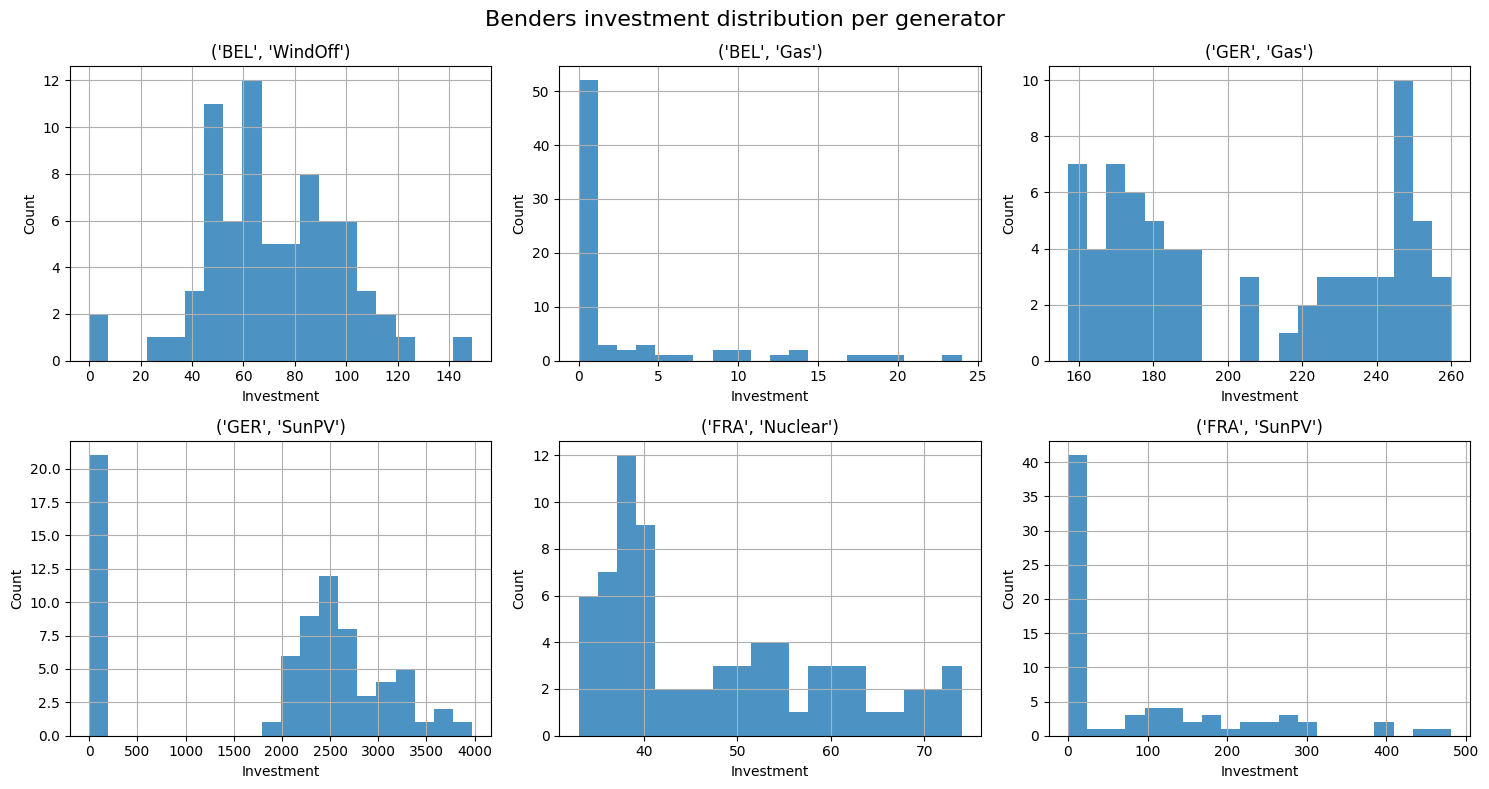

In [178]:
plot_generator_histograms(
    benders_inv,
    generator_names=[str(g) for g in const_data.G],
    bins=20,
    title="Benders investment distribution per generator"
)

### Compare differeent Investment Data

In [179]:
constrained_inv = const_data.pUnitInvestment.cpu().numpy()
print(constrained_inv.shape)

constrained_lb_inv = const_LB_data.pUnitInvestment.cpu().numpy()
print(constrained_lb_inv.shape)

unconstrained_inv = noconst_data.pUnitInvestment.cpu().numpy()
print(unconstrained_inv.shape)

(32768, 6)
(32768, 6)
(32768, 6)


In [180]:
import numpy as np
import pandas as pd

def summarize_investment(inv, name="dataset", zero_tol=1e-8):
    inv = np.asarray(inv, dtype=float)

    total_inv = inv.sum(axis=1)
    active_count = (np.abs(inv) > zero_tol).sum(axis=1)

    summary = {
        "dataset": name,
        "num_samples": inv.shape[0],
        "num_generators": inv.shape[1],
        "overall_mean": inv.mean(),
        "overall_median": np.median(inv),
        "overall_min": inv.min(),
        "overall_max": inv.max(),
        "fraction_zero": (np.abs(inv) <= zero_tol).mean(),
        "mean_total_investment": total_inv.mean(),
        "median_total_investment": np.median(total_inv),
        "min_total_investment": total_inv.min(),
        "max_total_investment": total_inv.max(),
        "mean_active_generators": active_count.mean(),
        "median_active_generators": np.median(active_count),
    }
    return pd.Series(summary, name=name)


def summarize_investments_table(investment_sets, zero_tol=1e-8, decimals=2):
    """
    Accepts either:
      - dict: {"benders": benders_inv, "constrained": constrained_inv}
      - list of tuples: [("benders", benders_inv), ("constrained", constrained_inv)]

    Returns:
      DataFrame with metrics as rows and dataset names as columns.
    """
    if isinstance(investment_sets, dict):
        items = investment_sets.items()
    else:
        items = investment_sets

    summaries = []
    for name, inv in items:
        s = summarize_investment(inv, name=name, zero_tol=zero_tol)
        summaries.append(s)

    df = pd.concat(summaries, axis=1)

    # keep text row as text, round numeric rows
    for idx in df.index:
        if idx != "dataset":
            df.loc[idx] = pd.to_numeric(df.loc[idx], errors="coerce").round(decimals)

    return df

In [182]:
table = summarize_investments_table({
    "benders": benders_inv,
    "constrained": constrained_inv,
    "constrained_lb": constrained_lb_inv,
    "unconstrained": unconstrained_inv,
})

table


,benders,constrained,constrained_lb,unconstrained
dataset,benders,constrained,constrained_lb,unconstrained
num_samples,73,32768,32768,32768
num_generators,6,6,6,6
overall_mean,384.28,286.51,527.12,500.0
overall_median,60.0,158.87,529.16,500.0
overall_min,-0.0,0.0,3.56,0.0
overall_max,3975.0,1000.0,999.99,1000.0
fraction_zero,0.22,0.0,0.0,0.0
mean_total_investment,2305.7,1719.06,3162.71,3000.0
median_total_investment,2793.0,1718.96,3164.62,2998.28


In [170]:
print(summarize_investments(constrained_inv, "constrained"))

dataset                     constrained
num_samples                       32768
num_generators                        6
overall_mean                 286.510602
overall_median               158.866158
overall_min                    0.001137
overall_max                  999.995313
fraction_zero                       0.0
mean_total_investment       1719.063609
median_total_investment     1718.957365
min_total_investment         173.033869
max_total_investment        3306.476513
mean_active_generators              6.0
median_active_generators            6.0
dtype: object


In [171]:
import numpy as np
import matplotlib.pyplot as plt

def plot_total_investment_hist(investment_sets, bins=40, title="Total investment per sample"):
    plt.figure(figsize=(8, 5))

    for name, inv in investment_sets.items():
        inv = np.asarray(inv, dtype=float)
        total_inv = inv.sum(axis=1)
        plt.hist(total_inv, bins=bins, alpha=0.45, label=name)

    plt.xlabel("Total investment")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

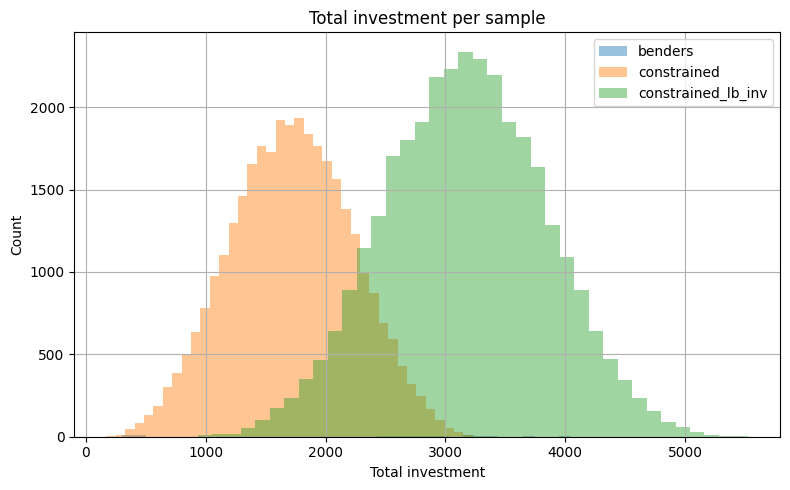

In [174]:
plot_total_investment_hist({
    "benders": benders_inv,
    "constrained": constrained_inv,
    "constrained_lb_inv": constrained_lb_inv,
    # "unconstrained": unconstrained_inv,
})

In [156]:
import numpy as np
import matplotlib.pyplot as plt

def plot_generator_box_compare(
    investment_sets,
    generator_names=None,
    showfliers=True,
):
    first_inv = next(iter(investment_sets.values()))
    num_g = np.asarray(first_inv, dtype=float).shape[1]

    if generator_names is None:
        generator_names = [f"G{i}" for i in range(num_g)]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for g in range(num_g):
        data_list = []
        labels = []

        for name, inv in investment_sets.items():
            inv = np.asarray(inv, dtype=float)
            data_list.append(inv[:, g])
            labels.append(name)

        axes[g].boxplot(
            data_list,
            labels=labels,
            showfliers=showfliers,
            patch_artist=True,
        )

        # optional colors
        colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
        for patch, color in zip(axes[g].artists, colors[:len(data_list)]):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)

        axes[g].set_title(str(generator_names[g]))
        axes[g].tick_params(axis="x", rotation=20)
        axes[g].set_ylabel("Investment")
        axes[g].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

/var/folders/3n/3c918lz14kd61yk6hgz4s1x40000gn/T/ipykernel_15987/2473920744.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[g].boxplot(
/var/folders/3n/3c918lz14kd61yk6hgz4s1x40000gn/T/ipykernel_15987/2473920744.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[g].boxplot(
/var/folders/3n/3c918lz14kd61yk6hgz4s1x40000gn/T/ipykernel_15987/2473920744.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[g].boxplot(
/var/folders/3n/3c918lz14kd61yk6hgz4s1x40000gn/T/ipykernel_15987/2473920744.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since M

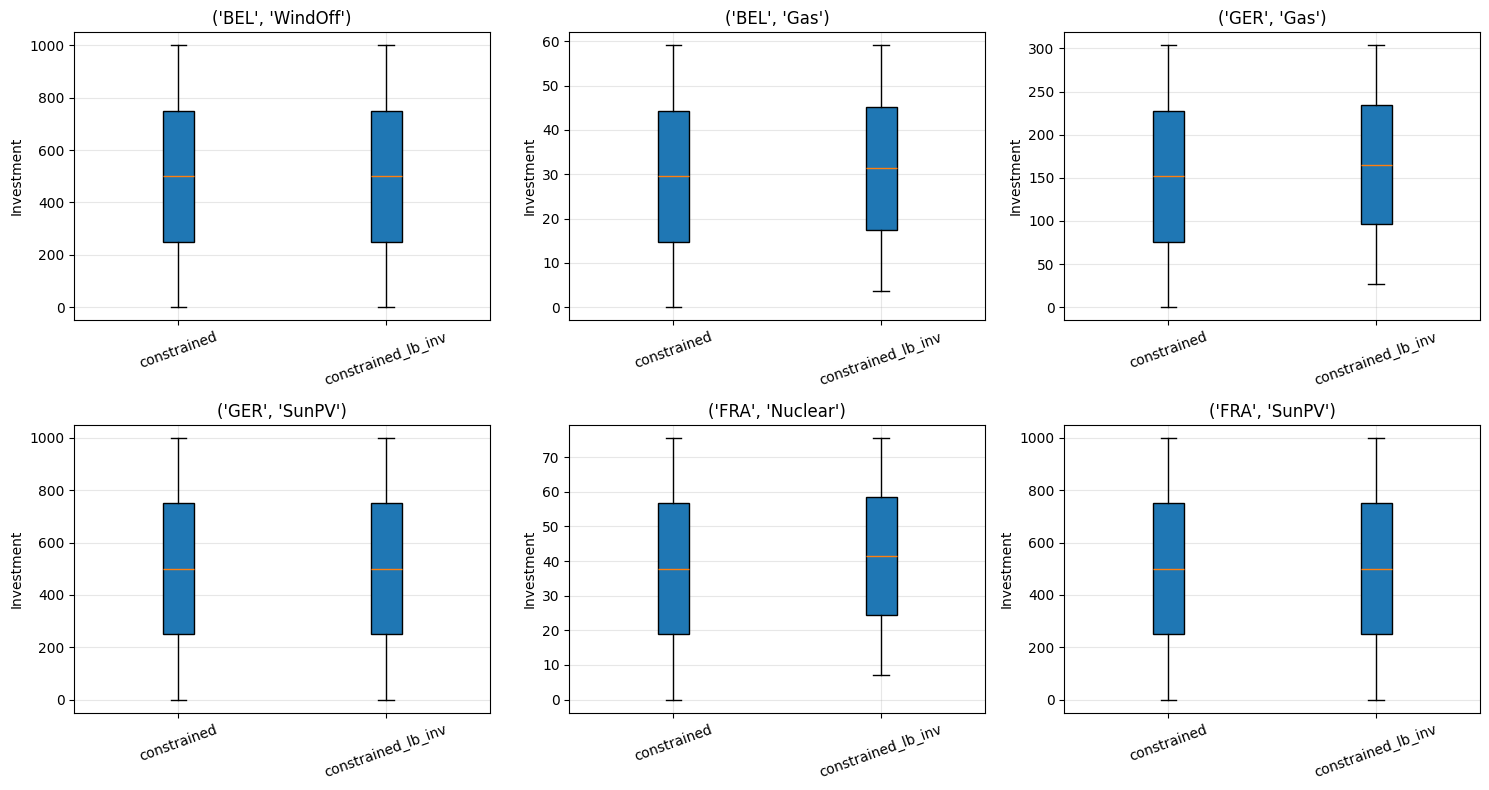

In [159]:
plot_generator_box_compare(
    {
        "constrained": constrained_inv,
        "constrained_lb_inv": constrained_lb_inv,
        # "unconstrained": unconstrained_inv,
    },
    generator_names=[str(g) for g in const_data.G],
    showfliers=False,
)

In [158]:
const_data.G

[('BEL', 'WindOff'),
 ('BEL', 'Gas'),
 ('GER', 'Gas'),
 ('GER', 'SunPV'),
 ('FRA', 'Nuclear'),
 ('FRA', 'SunPV')]